# CdpCAM MA2024 PC Stage8G Soma Probe

这个 notebook 用 `pc_stage8g_cdp_only_no_nak.ipynb` 的单 soma 参数，拆出一个三方对照：
- PC24 外部机制库里的 `cdp5_CAM`
- repo 里的 `CdpCAM_MA24_PC.mod`
- BrainCell 的 `CdpCAM_MA2024_PC`

目的不是复现整 morphology，而是先确认：`stage8g` 里大的 `cai` 误差，到底来自机制本身，还是来自整细胞几何/离散化。 


In [1]:
import os
import sys
import shutil
import subprocess
import tempfile
from pathlib import Path

repo_root = Path('/home/swl/braincell-ion_dyn').resolve()
if str(repo_root) in sys.path:
    sys.path.remove(str(repo_root))
sys.path.insert(0, str(repo_root))

os.environ.setdefault('JAX_PLATFORMS', 'cpu')

import brainstate
import brainunit as u
import matplotlib.pyplot as plt
import numpy as np

import braincell
from braincell import Branch, Cell, Morphology
from braincell.filter import BranchSlice, at
from neuron import h, load_mechanisms

print('braincell version:', braincell.__version__)
print('braincell import path:', Path(braincell.__file__).resolve())

brainstate.environ.set(precision=64)


braincell version: 0.1.0
braincell import path: /home/swl/braincell-ion_dyn/braincell/__init__.py


--No graphics will be displayed.


In [2]:
PC24_ROOT = Path('/home/swl/Cerebellum_circuit/PC24')
PC24_DLL = PC24_ROOT / 'x86_64' / '.libs' / 'libnrnmech.so'
repo_mod = repo_root / 'examples' / 'neuron_compare' / 'Cerebellum_mod' / 'PC' / 'ion' / 'CdpCAM_MA24_PC.mod'

assert PC24_DLL.exists(), PC24_DLL
assert repo_mod.exists(), repo_mod

dt_ms = 0.05
duration_ms = 10.0
temperature_celsius = 36.0
v_init_mV = -65.0
diam_um = 20.0
length_um = 20.0
total_pump_mol_cm2 = 5e-8

probe_fields = ['cai', 'pump', 'pumpca', 'CAM0']
print({
    'PC24_DLL': str(PC24_DLL),
    'repo_mod': str(repo_mod),
    'dt_ms': dt_ms,
    'duration_ms': duration_ms,
    'temperature_celsius': temperature_celsius,
    'v_init_mV': v_init_mV,
    'diam_um': diam_um,
    'length_um': length_um,
    'total_pump_mol_cm2': total_pump_mol_cm2,
})


{'PC24_DLL': '/home/swl/Cerebellum_circuit/PC24/x86_64/.libs/libnrnmech.so', 'repo_mod': '/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod', 'dt_ms': 0.05, 'duration_ms': 10.0, 'temperature_celsius': 36.0, 'v_init_mV': -65.0, 'diam_um': 20.0, 'length_um': 20.0, 'total_pump_mol_cm2': 5e-08}


In [3]:
compile_cmd = ['nrnivmodl', str(repo_mod)]
auto_tmpdir = Path(tempfile.mkdtemp(prefix='cdpcam_repo_stage8g_probe_'))
cpp = shutil.which('cpp') or '/usr/bin/cpp'
cc = shutil.which('cc') or '/usr/bin/cc'
cxx = shutil.which('c++') or '/usr/bin/c++'
print('Auto-compiling repo PC mod into:', auto_tmpdir)
proc = subprocess.run(
    compile_cmd,
    cwd=auto_tmpdir,
    env={**os.environ, 'CPP': cpp, 'CC': cc, 'CXX': cxx},
    capture_output=True,
    text=True,
)
print(proc.stdout)
if proc.returncode != 0:
    print(proc.stderr)
    raise RuntimeError('repo CdpCAM_MA24_PC.mod compile failed')

h.load_file('stdlib.hoc')
h.load_file('stdrun.hoc')
h.nrn_load_dll(str(PC24_DLL))
if not load_mechanisms(str(auto_tmpdir.resolve())):
    raise RuntimeError(f'Could not load compiled repo mechanisms from {auto_tmpdir}')
print('Loaded PC24 DLL and repo mod into the same fresh Python process.')


Auto-compiling repo PC mod into: /tmp/cdpcam_repo_stage8g_probe_uypp2x82
/tmp/cdpcam_repo_stage8g_probe_uypp2x82
Mod files: "/home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion//home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod"

Creating 'x86_64' directory for .o files.

 -> Compiling mod_func.cpp
 -> NMODL /home/swl/braincell-ion_dyn/examples/neuron_compare/Cerebellum_mod/PC/ion/CdpCAM_MA24_PC.mod
 -> Compiling CdpCAM_MA24_PC.c
 => LINKING shared library ./libnrnmech.so
 => LINKING executable ./special LDFLAGS are:    -pthread
Successfully created x86_64/special

Loaded PC24 DLL and repo mod into the same fresh Python process.


In [4]:
def run_neuron_density(suffix, totalpump_attr, refs):
    sec = h.Section(name=f'soma_{suffix}')
    sec.L = length_um
    sec.diam = diam_um
    sec.nseg = 1
    seg = sec(0.5)
    sec.insert(suffix)
    setattr(seg, totalpump_attr, total_pump_mol_cm2)

    h.celsius = temperature_celsius
    h.dt = dt_ms
    h.steps_per_ms = 1.0 / h.dt
    h.tstop = duration_ms
    h.v_init = v_init_mV

    vecs = {name: h.Vector().record(ref(seg)) for name, ref in refs.items()}
    h.finitialize(h.v_init)
    h.frecord_init()
    h.continuerun(h.tstop)
    return {name: np.asarray(vec, dtype=float) for name, vec in vecs.items()}

pc24_data = run_neuron_density(
    'cdp5_CAM',
    'TotalPump_cdp5_CAM',
    {
        't_ms': lambda seg: h._ref_t,
        'Ci': lambda seg: seg._ref_cai,
        'pump': lambda seg: seg._ref_pump_cdp5_CAM,
        'pumpca': lambda seg: seg._ref_pumpca_cdp5_CAM,
        'CAM0': lambda seg: seg._ref_CAM0_cdp5_CAM,
    },
)

repo_mod_data = run_neuron_density(
    'CdpCAM_MA24_PC',
    'TotalPump_CdpCAM_MA24_PC',
    {
        't_ms': lambda seg: h._ref_t,
        'Ci': lambda seg: seg._ref_cai,
        'pump': lambda seg: seg._ref_pump_CdpCAM_MA24_PC,
        'pumpca': lambda seg: seg._ref_pumpca_CdpCAM_MA24_PC,
        'CAM0': lambda seg: seg._ref_CAM0_CdpCAM_MA24_PC,
    },
)

print('PC24 start/end:', {k: (float(v[0]), float(v[-1])) for k, v in pc24_data.items() if k != 't_ms'})
print('Repo mod start/end:', {k: (float(v[0]), float(v[-1])) for k, v in repo_mod_data.items() if k != 't_ms'})


PC24 start/end: {'Ci': (4.5e-05, 3.682818549517757e-05), 'pump': (5e-08, 4.999994466806335e-08), 'pumpca': (0.0, 5.533193664670561e-14), 'CAM0': (0.03, 0.02988743304716643)}
Repo mod start/end: {'Ci': (4.5e-05, 3.682818549517757e-05), 'pump': (5e-08, 4.999994466806335e-08), 'pumpca': (0.0, 5.533193664670561e-14), 'CAM0': (0.03, 0.02988743304716643)}


In [5]:
soma = Branch.from_lengths(lengths=[length_um] * u.um, radii=[diam_um / 2.0, diam_um / 2.0] * u.um, type='soma')
morpho = Morphology.from_root(soma, name='soma')
cell = Cell(morpho, solver='staggered', V_init=v_init_mV * u.mV)
cell.paint(
    BranchSlice(branch_index=0, prox=0.0, dist=1.0),
    braincell.mech.Ion(
        'CdpCAM_MA2024_PC',
        name='ca',
        temp=u.celsius2kelvin(temperature_celsius),
        Co=2.0 * u.mM,
        Ci_initializer=45e-6 * u.mM,
        TotalPump=total_pump_mol_cm2 * (u.mol / u.cm**2),
    ),
)
cell.place(
    at('soma', 0.5),
    braincell.mech.MechanismProbe(mechanism='ca', field='Ci'),
    braincell.mech.MechanismProbe(mechanism='ca', field='pump'),
    braincell.mech.MechanismProbe(mechanism='ca', field='pumpca'),
    braincell.mech.MechanismProbe(mechanism='ca', field='CAM0'),
)

with brainstate.environ.context(precision=64):
    cell.init_state()
    result = cell.run(dt=dt_ms * u.ms, duration=duration_ms * u.ms)

braincell_data = {
    'Ci': np.asarray(result.traces['soma(0.5)_ca_Ci'].to_decimal(u.mM), dtype=float),
    'pump': np.asarray(result.traces['soma(0.5)_ca_pump'].to_decimal(u.mol / u.cm**2), dtype=float),
    'pumpca': np.asarray(result.traces['soma(0.5)_ca_pumpca'].to_decimal(u.mol / u.cm**2), dtype=float),
    'CAM0': np.asarray(result.traces['soma(0.5)_ca_CAM0'].to_decimal(u.mM), dtype=float),
}
print('BrainCell start/end:', {k: (float(v[0]), float(v[-1])) for k, v in braincell_data.items()})


BrainCell start/end: {'Ci': (3.772659674806105e-05, 3.682818557410762e-05), 'pump': (4.99999997170518e-08, 4.9999944668063786e-08), 'pumpca': (2.8294819839173263e-16, 5.533193621091865e-14), 'CAM0': (0.02999252887911615, 0.029887433046397467)}


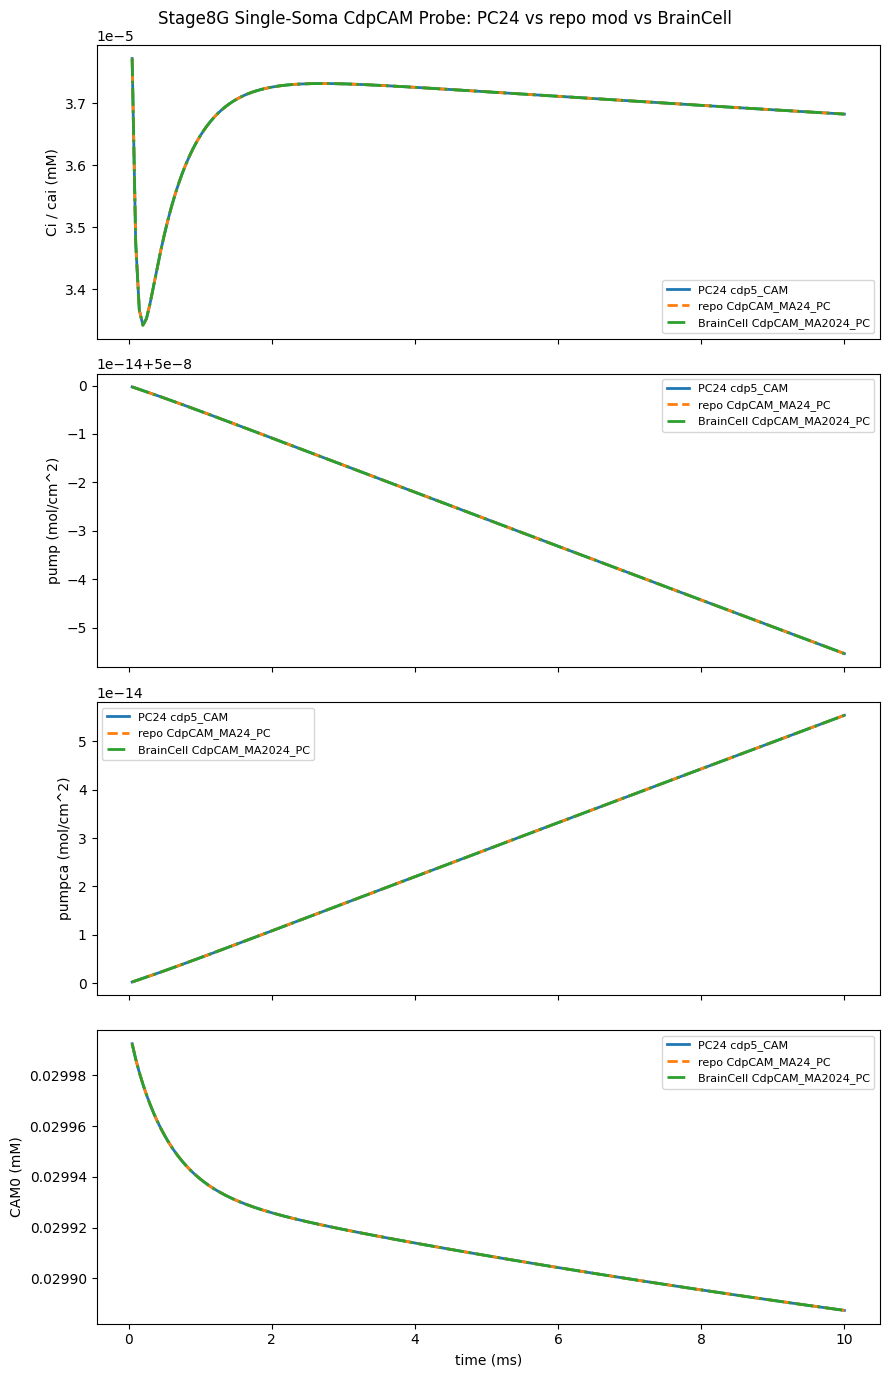

repo_vs_pc24:
Ci {'rmse': 0.0, 'max_abs': 0.0, 'start': (3.772668986337782e-05, 3.772668986337782e-05), 'end': (3.682818549517757e-05, 3.682818549517757e-05)}
pump {'rmse': 0.0, 'max_abs': 0.0, 'start': (4.99999997170511e-08, 4.99999997170511e-08), 'end': (4.999994466806335e-08, 4.999994466806335e-08)}
pumpca {'rmse': 0.0, 'max_abs': 0.0, 'start': (2.829488986139156e-16, 2.829488986139156e-16), 'end': (5.533193664670561e-14, 5.533193664670561e-14)}
CAM0 {'rmse': 0.0, 'max_abs': 0.0, 'start': (0.02999252855233975, 0.02999252855233975), 'end': (0.02988743304716643, 0.02988743304716643)}

brain_vs_pc24:
Ci {'rmse': 1.6256897127440902e-11, 'max_abs': 1.0820495116369922e-10, 'start': (3.772659674806105e-05, 3.772668986337782e-05), 'end': (3.682818557410762e-05, 3.682818549517757e-05)}
pump {'rmse': 2.086699740272048e-21, 'max_abs': 4.963083675318166e-21, 'start': (4.99999997170518e-08, 4.99999997170511e-08), 'end': (4.9999944668063786e-08, 4.999994466806335e-08)}
pumpca {'rmse': 2.086227649

In [6]:
pc24_cmp = {k: v[1:] for k, v in pc24_data.items() if k != 't_ms'}
repo_cmp = {k: v[1:] for k, v in repo_mod_data.items() if k != 't_ms'}
time_ms = pc24_data['t_ms'][1:]

def summarize(a, b):
    diff = np.asarray(a) - np.asarray(b)
    return {
        'rmse': float(np.sqrt(np.mean(diff ** 2))),
        'max_abs': float(np.max(np.abs(diff))),
        'start': (float(a[0]), float(b[0])),
        'end': (float(a[-1]), float(b[-1])),
    }

repo_vs_pc24 = {k: summarize(repo_cmp[k], pc24_cmp[k]) for k in ['Ci', 'pump', 'pumpca', 'CAM0']}
brain_vs_pc24 = {k: summarize(braincell_data[k], pc24_cmp[k]) for k in ['Ci', 'pump', 'pumpca', 'CAM0']}

fig, axes = plt.subplots(4, 1, figsize=(9, 14), sharex=True)
for ax, field, ylabel in zip(
    axes,
    ['Ci', 'pump', 'pumpca', 'CAM0'],
    ['Ci / cai (mM)', 'pump (mol/cm^2)', 'pumpca (mol/cm^2)', 'CAM0 (mM)'],
):
    ax.plot(time_ms, pc24_cmp[field], label='PC24 cdp5_CAM', linewidth=2)
    ax.plot(time_ms, repo_cmp[field], '--', label='repo CdpCAM_MA24_PC', linewidth=2)
    ax.plot(time_ms, braincell_data[field], '-.', label='BrainCell CdpCAM_MA2024_PC', linewidth=2)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8)
axes[-1].set_xlabel('time (ms)')
plt.suptitle('Stage8G Single-Soma CdpCAM Probe: PC24 vs repo mod vs BrainCell')
plt.tight_layout()
plt.show()

print('repo_vs_pc24:')
for name, summary in repo_vs_pc24.items():
    print(name, summary)

print('\nbrain_vs_pc24:')
for name, summary in brain_vs_pc24.items():
    print(name, summary)
